In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import illustris_python as il

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False

plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:

def running_percentiles(xdata, ydata, window_size, percentiles=[50], dx=0.1):
    # Calculate the running standard deviation
    nbins = int((max(xdata) - min(xdata[xdata>0]))/dx)
    
    
    bin_first = min(xdata[xdata>0]) + (window_size/2)
    bin_last = max(xdata) - (window_size/2)
    bins = np.linspace(bin_first, bin_last, nbins)

    
    running_percentile_arr = np.zeros((len(percentiles),nbins), dtype=float)
    bin_cents = np.zeros_like(bins, dtype=float)
    for i, bin in enumerate(bins):
        bin_max = bin+window_size/2
        bin_min = bin-window_size/2
        bin_mask = (xdata < bin_max) & (xdata > bin_min)
        if i < window_size - 1:
            running_percentile_arr[i] = np.nan  # Not enough data points for the window
        else:   
            for ip, percentile in enumerate(percentiles):
                running_percentile_arr[ip][i] = np.percentile(ydata[bin_mask], q=percentile)
            bin_cents[i] = np.median(xdata[bin_mask])
    return bin_cents, running_percentile_arr



In [4]:
def read_data(sim_dir, data_type="cent"):
    if data_type == "cent":
        sim_data1 = np.loadtxt(f"{sim_dir}/sfr-halomass_central.txt")

        ihalo_sim1 =  sim_data1[:,0]
        mhalo_sim1 = sim_data1[:,1]
        sfr_sim1 = sim_data1[:,5]

        sim_data2 = np.loadtxt(f"{sim_dir}/sfr-cent_0sfr.txt")

        ihalo_sim2 =  sim_data2[:,0]
        mhalo_sim2 = sim_data2[:,1]
        sfr_sim2 = sim_data2[:,5]

        ihalo_sim3 = np.concatenate((ihalo_sim1,ihalo_sim2))
        mhalo_sim3 = np.concatenate((mhalo_sim1,np.round(mhalo_sim2,4)))
        sfr_sim3 = np.concatenate((sfr_sim1,sfr_sim2))
    elif data_type == "sat_sum":
        sim_data3 = np.loadtxt(f"{sim_dir}/sat_submass_sum_logM10.txt")
        ihalo_sim3 =  sim_data3[:,0]
        mhalo_sim3 = None
        sfr_sim3 = sim_data3[:,1]
        
    elif data_type == "group":
        sim_data3 = np.loadtxt(f"{sim_dir}/sfr-halomass_sum.txt")
        ihalo_sim3 =  sim_data3[:,0]
        mhalo_sim3 = sim_data3[:,1]
        sfr_sim3 = sim_data3[:,5]
        
    
    return ihalo_sim3, mhalo_sim3, sfr_sim3

In [5]:
snapnum = 40

In [6]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [7]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [8]:
h = 0.6774

In [9]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/tmp/ipykernel_2209026/565162213.py:1: RuntimeWarning: divide by zero encountered in log10
  mvir = np.log10(halos["Group_M_TopHat200"]*1e10)


In [10]:
group_sfrs = np.log10(halos["GroupSFR"])

/tmp/ipykernel_2209026/618587702.py:1: RuntimeWarning: divide by zero encountered in log10
  group_sfrs = np.log10(halos["GroupSFR"])


In [11]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10


<class 'dict'>


In [12]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [13]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/tmp/ipykernel_2209026/3847561726.py:4: RuntimeWarning: divide by zero encountered in log10
  cent_sfrs = np.log10(cent_sfrs)


In [14]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [15]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [16]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [17]:
sum_sfrs = np.zeros(len(group_sfrs))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/tmp/ipykernel_2209026/1283956768.py:3: RuntimeWarning: divide by zero encountered in log10
  sum_sfrs = np.log10(sum_sfrs)


In [18]:
cent_tot = np.sum(10**cent_sfrs)
print(cent_tot)
sat_tot = np.sum(10**sum_sfrs)
print(sat_tot)
gal_tot = cent_tot+sat_tot
print(gal_tot)
print(sat_tot/gal_tot)

825938.4380616396
362224.35891091614
1188162.7969725556
0.3048608825607615


In [19]:
group_tot = np.sum(10**group_sfrs)
print(group_tot)

1189226.6


In [20]:
gal_tot/group_tot

0.9991054455012354

In [21]:
percentiles_list = [10, 25, 50, 75, 90]
window_size=0.2
dlogM= 0.1

In [22]:
bin_cents_cent, percentiles_cent = running_percentiles(mvir, cent_sfrs, window_size, percentiles=percentiles_list, dx=dlogM)
bin_cents_sat, percentiles_sat = running_percentiles(mvir, sum_sfrs, window_size, percentiles=percentiles_list, dx=dlogM)
bin_cents_group, percentiles_group = running_percentiles(mvir, group_sfrs, window_size, percentiles=percentiles_list, dx=dlogM)


/cosma/home/dp004/dc-zhan5/nbodykit_venv/lib/python3.12/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [23]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2209026/3455635808.py:19: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')


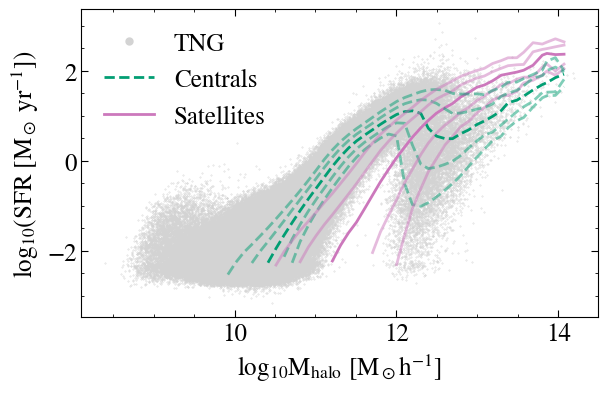

<Figure size 666.667x400 with 0 Axes>

In [24]:
plt.scatter(mvir, cent_sfrs, s=0.1, color="lightgrey", label="TNG")

#tng_scatter = plt.scatter(mhalo_tng, sfr_tng, s=0.1, color="lightgrey", label=TNG)
color_list = palette_tab10[1:2] + palette_tab10[2:3] + palette_tab10[4:5]
for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
    else:
        alpha = 0.5
    #plt.plot(bin_cents_group, percentiles_group[i], linestyle="dashed", color=color_list[0], alpha=alpha, linewidth = 2)
    plt.plot(bin_cents_cent, percentiles_cent[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
    plt.plot(bin_cents_sat, percentiles_sat[i], color=color_list[2],alpha = alpha)

tng_scatter = Line2D([],[], marker=".", linewidth=0, markersize=10, color="lightgrey", label="TNG")
tng = Line2D([],[], linestyle="dashed", color=color_list[1], label="Centrals")
eagle = Line2D([],[], linestyle="solid", color=color_list[2], label="Satellites")
plt.legend(handles=[tng_scatter, tng,eagle], loc="upper left")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
#plt.ylim(-2,2.3)
plt.xlim()
plt.show()
plt.clf()

In [25]:
def running_fraction(xdata, ydata, window_size, lower_lim = -3, dx=0.1):
    # Calculate the running standard deviation
    nbins = int((max(xdata) - min(xdata[xdata>0]))/dx)
    
    bin_first = min(xdata[xdata>0]) + (window_size/2)
    bin_last = max(xdata) - (window_size/2)
    bins = np.linspace(bin_first, bin_last, nbins)

    running_frac_arr = np.zeros_like(bins, dtype=float)
    bin_cents = np.zeros_like(bins, dtype=float)
    for i, bin in enumerate(bins):
        bin_max = bin+window_size/2
        bin_min = bin-window_size/2
        bin_mask = (xdata < bin_max) & (xdata > bin_min)
        lim_mask = ydata[bin_mask] < lower_lim
        if i < window_size - 1:
            running_frac_arr[i] = np.nan  # Not enough data points for the window
        else:   
            running_frac_arr[i] = np.sum(lim_mask)/np.sum(bin_mask)
            bin_cents[i] = np.median(xdata[bin_mask])
    return bin_cents, running_frac_arr



In [26]:
bin_cents_frac_cent, cent_frac = running_fraction(mvir, cent_sfrs, window_size,lower_lim = -2, dx=dlogM)

In [27]:
bin_cents_frac_sat, sat_frac = running_fraction(mvir, sum_sfrs, window_size,lower_lim = -2, dx=dlogM)

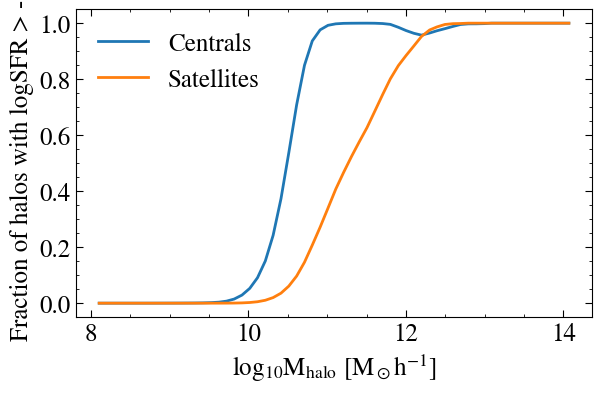

In [28]:
plt.plot(bin_cents_frac_cent, 1-cent_frac, label="Centrals")
plt.plot(bin_cents_frac_sat, 1-sat_frac, label="Satellites")
plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel(r"Fraction of halos with logSFR > -2")
plt.legend()

<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:23: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2209026/2120363347.py:23: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')


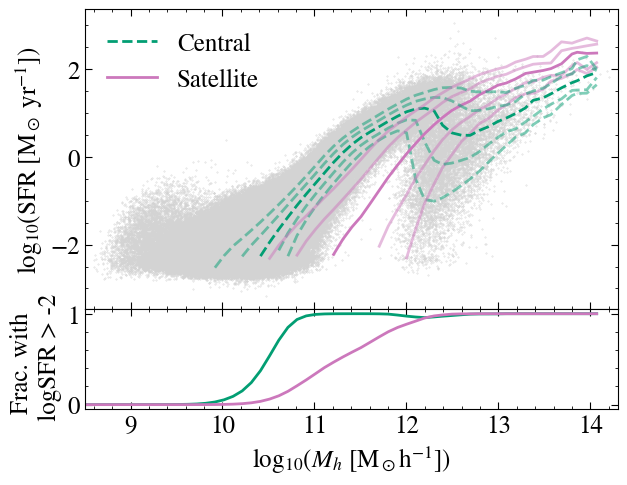

<Figure size 666.667x400 with 0 Axes>

In [32]:
figsize=(2*10/3, 2*2.5)
fig1 = plt.figure(figsize=figsize)
frame1 = fig1.add_axes((.1,.3,.8,.6))

plt.scatter(mvir, cent_sfrs, s=0.1, color="lightgrey", label="Centrals")

#tng_scatter = plt.scatter(mhalo_tng, sfr_tng, s=0.1, color="lightgrey", label=TNG)
color_list = palette_tab10[1:2] + palette_tab10[2:3] + palette_tab10[4:5]
for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
    else:
        alpha = 0.5
    #plt.plot(bin_cents_group, percentiles_group[i], linestyle="dashed", color=color_list[0], alpha=alpha, linewidth = 2)
    plt.plot(bin_cents_cent, percentiles_cent[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
    plt.plot(bin_cents_sat, percentiles_sat[i], color=color_list[2],alpha = alpha)

tng_scatter = Line2D([],[], marker=".", linewidth=0, markersize=10, color="lightgrey", label="Centrals")
cent_leg = Line2D([],[], linestyle="dashed", color=color_list[1], label="Central")
sat_leg = Line2D([],[], linestyle="solid", color=color_list[2], label="Satellite")
plt.legend(handles=[cent_leg, sat_leg], loc="upper left")
#plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')

plt.xlim(8.5, 14.3)

frame2 = fig1.add_axes((.1,.1,.8,.2), sharex=frame1) 

plt.plot(bin_cents_frac_cent, 1-cent_frac, label="Centrals", color=color_list[1])
plt.plot(bin_cents_frac_sat, 1-sat_frac, label="Satellites", color=color_list[2])
plt.xlabel(r"log$_{10}(M_h$ [M$_\odot$h$^{-1}$])")
plt.ylabel("Frac. with \n logSFR > -2")
plt.savefig("../figures/sfr-mvir_cent_sat.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
plt.clf()

In [30]:
bin_cents_frac_group, group_frac = running_fraction(mvir, group_sfrs, window_size,lower_lim = -2, dx=dlogM)

<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2209026/456971108.py:22: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')


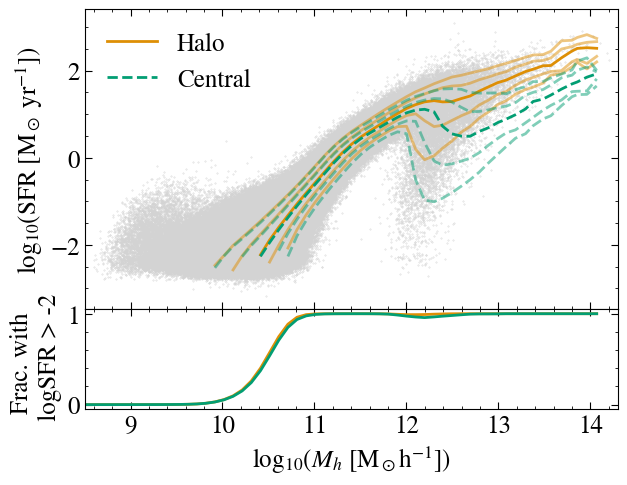

<Figure size 666.667x400 with 0 Axes>

In [33]:
figsize=(2*10/3, 2*2.5)
fig1 = plt.figure(figsize=figsize)
frame1 = fig1.add_axes((.1,.3,.8,.6))

plt.scatter(mvir, group_sfrs, s=0.1, color="lightgrey", label="Group")

#tng_scatter = plt.scatter(mhalo_tng, sfr_tng, s=0.1, color="lightgrey", label=TNG)
color_list = palette_tab10[1:2] + palette_tab10[2:3] + palette_tab10[4:5]
for i in range(len(percentiles_list)):
    if i == 2:
        alpha = 1
    else:
        alpha = 0.5
    plt.plot(bin_cents_group, percentiles_group[i], linestyle="solid", color=color_list[0], alpha=alpha, linewidth = 2)
    plt.plot(bin_cents_cent, percentiles_cent[i], linestyle="dashed", color=color_list[1], alpha=alpha, linewidth = 2)
    
tng_scatter = Line2D([],[], marker=".", linewidth=0, markersize=10, color="lightgrey", label="Halo")
group = Line2D([],[], linestyle="solid", color=color_list[0], label="Halo")
cent = Line2D([],[], linestyle="dashed", color=color_list[1], label="Central")
plt.legend(handles=[group, cent], loc="upper left")
#plt.xlabel(r"log$_{10}$M$_{\rm halo}$ [M$_\odot$h$^{-1}$]")
plt.ylabel('log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')

plt.xlim(8.5, 14.3)

frame2 = fig1.add_axes((.1,.1,.8,.2), sharex=frame1) 

plt.plot(bin_cents_frac_group, 1-group_frac, label="Group", color=color_list[0])
plt.plot(bin_cents_frac_cent, 1-cent_frac, label="Centrals", color=color_list[1])
plt.xlabel(r"log$_{10}(M_h$ [M$_\odot$h$^{-1}]$)")
plt.ylabel("Frac. with \n logSFR > -2")
plt.savefig("../figures/sfr-mvir_group_cent.png", format="png", bbox_inches="tight", dpi=300)
plt.show()
plt.clf()